# CC53 - Procesamiento de Imagenes
## Practica Integradora: Inspeccion Visual Automatizada de Obleas de Semiconductor

**Modalidad:** individual | **Entorno:** Jupyter Notebook | **Temario:** Redes Neuronales Convolucionales, Segmentacion Semantica (U-Net) y Deteccion de Objetos.

---

### Contexto del caso

La empresa **NorAndes Semiconductores S.A.** opera una linea de fabricacion de obleas (*wafers*) de silicio. Una camara de inspeccion de 12 bits captura una imagen de cada oblea al final de la linea. La planta necesita un sistema de vision que, en tres etapas, decida automaticamente el destino de cada pieza:

1. **Triaje (clasificacion CNN):** decidir si la oblea presenta defectos o esta limpia.
2. **Localizacion fina (segmentacion semantica):** si esta defectuosa, marcar a nivel de pixel las regiones danadas.
3. **Conteo e identificacion (deteccion):** delimitar y contar cada defecto individual para el reporte de calidad.

Usted es el ingeniero de vision asignado. **En cada etapa se le presentan TRES bloques de codigo alternativos (Opcion A, B y C).** Su tarea no es programar desde cero, sino **elegir el bloque mas adecuado para este escenario y justificar su eleccion con los valores numericos que usted mismo obtenga al ejecutar la practica.**

---

### Reglas de integridad academica (LEER ANTES DE EMPEZAR)

- **Sus datos son unicos.** El conjunto de obleas se genera a partir de una semilla derivada de **su codigo de matricula**. Las imagenes, las estadisticas y, en varios bloques, la respuesta correcta **cambian de un alumno a otro**. Copiar la respuesta de un companero o de una herramienta externa producira valores que **no coinciden con su semilla** y sera detectado.
- **Toda justificacion debe citar valores de SU ejecucion.** No se aceptan definiciones genericas de libro: debe escribir los numeros exactos que imprimio su notebook (media, ratio de desbalance, IoU, conteos, etc.) y razonar a partir de ellos.
- **Entrega obligatoria de un Token de Verificacion** (ultima celda). Ese token combina su codigo, sus elecciones y la huella de sus datos. El docente lo recomputa para validar que usted ejecuto su propio notebook con las elecciones que declara. Un token ausente, alterado o inconsistente invalida la entrega.
- No se permite el uso de asistentes de IA para resolver los bloques. Aun cuando un asistente "adivine" una letra, **no podra producir sus valores de ejecucion ni un token valido**, por lo que la justificacion quedara vacia o incorrecta.

> **[!] El notebook esta disenado para ejecutarse de principio a fin sin errores aun antes de que usted decida.** Cada bloque trae una eleccion **por defecto** para que todo corra; esa eleccion por defecto **no necesariamente es la correcta** y debe ser revisada y justificada por usted.

### Como trabajar esta practica

1. Ejecute las celdas en orden (menu *Kernel -> Restart & Run All* al inicio para verificar que todo corre).
2. En **Paso 0**, reemplace su codigo de matricula. Esto fija su semilla.
3. Para cada bloque (1 a 5): lea el enunciado, ejecute la celda de las tres opciones, **fije su eleccion** en la variable `CHOICE_...`, vuelva a ejecutar y complete la celda de **Justificacion** con sus numeros.
4. Conteste la **Reflexion contextual**.
5. Ejecute la **celda del Token** y peguelo en su informe de entrega.

**Tiempo de ejecucion aproximado:** 1-2 minutos en CPU (no requiere GPU).

In [1]:
# ============================================================
# Configuracion del entorno
# ============================================================
import hashlib
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy import ndimage

torch.set_num_threads(2)
WAFER_SIZE = 64           # resolucion de la imagen de inspeccion (px)
ADC_MAX = 4095            # sensor de 12 bits -> rango [0, 4095]
print("Entorno listo. PyTorch", torch.__version__)

Entorno listo. PyTorch 2.11.0+cpu


## Paso 0 - Identificacion del alumno

Reemplace el valor de `CODIGO_ALUMNO` por **su codigo de matricula UPC** (formato `uXXXXXXXX`). De este codigo se deriva la semilla que genera **su** conjunto de obleas. No comparta su semilla ni sus datos.

In [ ]:
# ============================================================
# [!] REEMPLACE su codigo de matricula antes de continuar
# ============================================================
CODIGO_ALUMNO = "uXXXXXXX"   # <-- EDITAR

if CODIGO_ALUMNO == "u00000000":
    print("[!] ADVERTENCIA: esta usando el codigo por defecto 'u00000000'.")
    print("[!] Reemplacelo por su codigo real o su entrega no sera valida.")

SEED = int(hashlib.sha256(CODIGO_ALUMNO.encode()).hexdigest(), 16) % (2**31)
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
print("Codigo:", CODIGO_ALUMNO, "| Semilla derivada (SEED):", SEED)

Codigo: u20221C464 | Semilla derivada (SEED): 1068274239


## Paso 1 - Generacion del conjunto de inspeccion

Se sintetizan obleas con defectos circulares de contraste y tamano variables sobre una superficie con textura. Como los datos son sinteticos, conocemos el **ground truth exacto**: etiqueta (defectuosa / limpia), **mascara** de pixeles danados y **cajas** de cada defecto. Todo se deriva de su `SEED`.

In [3]:
# ============================================================
# Generador de obleas sinteticas (ground truth exacto)
# ============================================================
def make_wafer(rng, defective):
    # Devuelve (imagen_raw_12bit, mascara, lista_de_cajas).
    base = 0.45 + 0.05 * rng.standard_normal()
    img = np.full((WAFER_SIZE, WAFER_SIZE), base, dtype=np.float32)
    yy, xx = np.mgrid[0:WAFER_SIZE, 0:WAFER_SIZE]
    img += 0.06 * (xx / WAFER_SIZE) + 0.02 * rng.standard_normal((WAFER_SIZE, WAFER_SIZE)).astype(np.float32)
    mask = np.zeros((WAFER_SIZE, WAFER_SIZE), dtype=np.float32)
    boxes = []
    if defective:
        n_def = int(rng.integers(1, 5))            # 1 a 4 defectos
        for _ in range(n_def):
            r = int(rng.integers(4, 10))           # radio del defecto
            cx = int(rng.integers(r + 2, WAFER_SIZE - r - 2))
            cy = int(rng.integers(r + 2, WAFER_SIZE - r - 2))
            dist2 = (xx - cx) ** 2 + (yy - cy) ** 2
            blob = dist2 <= r * r
            polarity = -1 if rng.random() < 0.5 else 1
            img[blob] += polarity * (0.42 + 0.12 * rng.random())
            mask[blob] = 1.0
            boxes.append([cx - r, cy - r, cx + r, cy + r])
    img = np.clip(img, 0.0, 1.0)
    raw = (img * ADC_MAX).astype(np.int32)         # lectura del sensor de 12 bits
    return raw, mask, boxes

def build_set(rng, n, frac_def=0.5):
    X, M, B, Y = [], [], [], []
    for _ in range(n):
        defe = rng.random() < frac_def
        raw, mask, boxes = make_wafer(rng, defe)
        X.append(raw); M.append(mask); B.append(boxes); Y.append(int(defe))
    return np.array(X), np.array(M), B, np.array(Y)

X_train_raw, M_train, B_train, Y_train = build_set(rng, 200)
X_val_raw,   M_val,   B_val,   Y_val   = build_set(rng, 50)
print("Conjunto generado:", X_train_raw.shape[0], "obleas de entrenamiento,",
      X_val_raw.shape[0], "de validacion.")
print("Rango de intensidad (12 bits):", int(X_train_raw.min()), "-", int(X_train_raw.max()))

Conjunto generado: 200 obleas de entrenamiento, 50 de validacion.
Rango de intensidad (12 bits): 0 - 4095


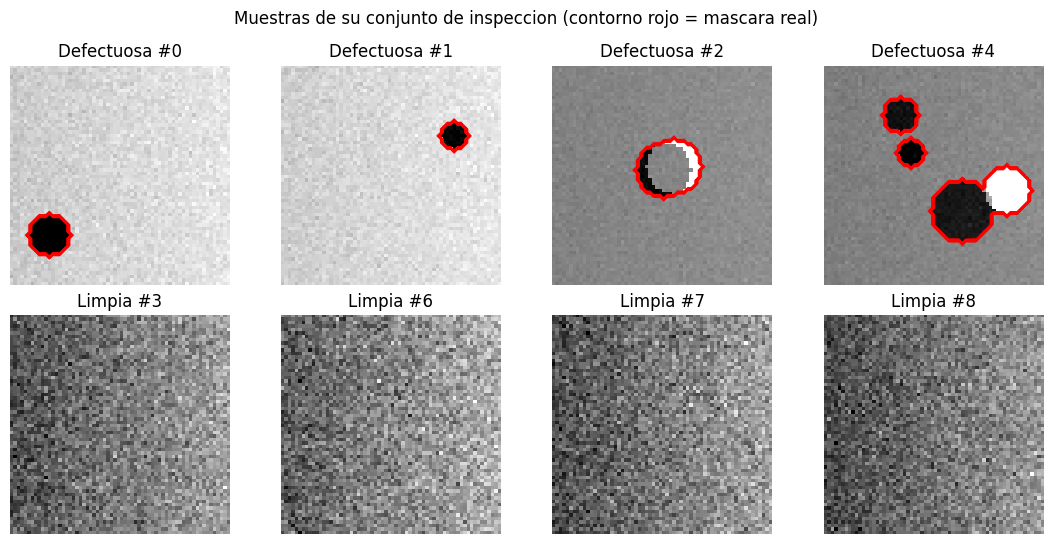

In [4]:
# Visualizacion de algunas obleas de SU conjunto
fig, axes = plt.subplots(2, 4, figsize=(11, 5.5))
idx_def = [i for i in range(len(Y_train)) if Y_train[i] == 1][:4]
idx_ok  = [i for i in range(len(Y_train)) if Y_train[i] == 0][:4]
for col, i in enumerate(idx_def):
    axes[0, col].imshow(X_train_raw[i], cmap="gray"); axes[0, col].set_title(f"Defectuosa #{i}")
    axes[0, col].contour(M_train[i], colors="red", linewidths=0.8); axes[0, col].axis("off")
for col, i in enumerate(idx_ok):
    axes[1, col].imshow(X_train_raw[i], cmap="gray"); axes[1, col].set_title(f"Limpia #{i}")
    axes[1, col].axis("off")
axes[0,0].set_ylabel("Defectuosas");
plt.suptitle("Muestras de su conjunto de inspeccion (contorno rojo = mascara real)")
plt.tight_layout(); plt.show()

In [5]:
# ============================================================
# Estadisticas del conjunto (VALORES ANCLA - los usara para justificar)
# ============================================================
DATA_MEAN = float(X_train_raw.mean())
DATA_STD  = float(X_train_raw.std())
fg_pixels = float(M_train.sum())
IMBALANCE_RATIO = fg_pixels / M_train.size      # fraccion de pixeles defecto
diam_list = [b[2] - b[0] for bs in B_train for b in bs]
MEDIAN_DIAMETER = int(np.median(diam_list)) if diam_list else 0
N_DEFECTS_TOTAL = int(sum(len(bs) for bs in B_train))

print("---- Estadisticas de SU conjunto ----")
print(f"Media de intensidad (raw 12 bits) : {DATA_MEAN:.2f}")
print(f"Desv. estandar (raw 12 bits)      : {DATA_STD:.2f}")
print(f"Ratio de desbalance (defecto/total): {IMBALANCE_RATIO:.4f}  ->  {100*IMBALANCE_RATIO:.2f}% de pixeles son defecto")
print(f"Diametro mediano de defecto       : {MEDIAN_DIAMETER} px")
print(f"Total de defectos (entrenamiento) : {N_DEFECTS_TOTAL}")

---- Estadisticas de SU conjunto ----
Media de intensidad (raw 12 bits) : 1988.70
Desv. estandar (raw 12 bits)      : 435.23
Ratio de desbalance (defecto/total): 0.0375  ->  3.75% de pixeles son defecto
Diametro mediano de defecto       : 12 px
Total de defectos (entrenamiento) : 241


## Bloque 1 - Preprocesamiento de la entrada para la CNN

La camara entrega valores enteros de 12 bits (rango 0 a 4095). Antes de alimentar la CNN debe decidir como escalar esa entrada. Tiene tres opciones:

- **Opcion A - Sin normalizacion:** usar los valores crudos del sensor tal cual (`float` en rango 0-4095).
- **Opcion B - Min-max a [0, 1]:** dividir por el maximo del rango (4095).
- **Opcion C - Estandarizacion (z-score):** restar la media del conjunto y dividir por su desviacion estandar.

Ejecute la celda: imprime la **media y desviacion** que tendria la entrada bajo cada opcion. Luego fije su eleccion en `CHOICE_PREPROC`.

In [6]:
# Diagnostico: estadisticas de la entrada bajo cada opcion
A_in = X_train_raw.astype(np.float32)
B_in = X_train_raw / float(ADC_MAX)
C_in = (X_train_raw - DATA_MEAN) / (DATA_STD + 1e-6)
for name, arr in [("A sin normalizar", A_in), ("B min-max", B_in), ("C z-score", C_in)]:
    print(f"  Opcion {name:16s}: media={arr.mean():8.3f}  std={arr.std():8.3f}")

# ----- Definicion de cada opcion de preprocesamiento -----
def preproc_A(raw): return raw.astype(np.float32)
def preproc_B(raw): return raw / float(ADC_MAX)
def preproc_C(raw): return (raw - DATA_MEAN) / (DATA_STD + 1e-6)
_PREPROC = {"A": preproc_A, "B": preproc_B, "C": preproc_C}

# ============================================================
# [!] FIJE SU ELECCION (por defecto 'C' para que el notebook corra)
# ============================================================
CHOICE_PREPROC = "C"   # <-- EDITAR si corresponde

prep = _PREPROC[CHOICE_PREPROC]
Xtr = torch.tensor(prep(X_train_raw)).unsqueeze(1).float()
Xva = torch.tensor(prep(X_val_raw)).unsqueeze(1).float()
Ytr = torch.tensor(Y_train); Yva = torch.tensor(Y_val)
print(f"\nPreprocesamiento aplicado: Opcion {CHOICE_PREPROC} | entrada std={float(Xtr.std()):.3f}")

  Opcion A sin normalizar: media=1988.704  std= 435.235
  Opcion B min-max       : media=   0.486  std=   0.106
  Opcion C z-score       : media=  -0.000  std=   1.000

Preprocesamiento aplicado: Opcion C | entrada std=1.000


### Justificacion - Bloque 1

> **[!] Complete con los valores que imprimio su celda. Una justificacion sin numeros propios no recibe puntaje.**

- **Mi eleccion:** Opcion `C`
- **Valores observados (media / std por opcion):** C: -0.000 / 1.000
- **Justificacion (3-5 lineas, ligada a su escenario):** Mi conjunto representa una media de intensidad de 1988.70 y una desviacion estandar de 435.23. La transformacion de `(x-1988.70) / 435.23` centra los datos en media cero y varianza uno. Esto favorece la estabilidad numerica y acelera la convergencia durante el entrenamiento de la CNN
- **Por que descarto las otras dos:** Descarte la opcion A porque mantiene valores grandes (0-4095) lo que dificulta la optimizacion de la red. Y con respecto a la opcion B esta reduce el rango de los datos, no considera la distribucion estadistica del conjunto. Los datos no quedarian centrados.

## Bloque 2 - Arquitectura de la CNN clasificadora

Debe elegir la profundidad/agresividad de submuestreo de la red de triaje. Recuerde: cada `MaxPool2d(2)` divide la resolucion espacial entre 2, y un defecto pequeno puede desaparecer si se aplica demasiado *pooling*. Tres opciones:

- **Opcion A - Superficial, kernel grande:** 1 capa conv 7x7 + 1 pooling. Alta resolucion, pocos parametros, campo receptivo pequeno.
- **Opcion B - Pila de 3x3 (moderada):** 3 conv 3x3 + 2 pooling. Equilibrio entre resolucion y contexto.
- **Opcion C - Profunda, mucho pooling:** 4 conv + 4 pooling. Campo receptivo amplio pero resolucion final minima.

Ejecute: la celda imprime para cada arquitectura el numero de parametros, la **resolucion espacial de salida** (antes del *pooling* global) y un campo receptivo aproximado, junto al **diametro mediano de defecto** de su conjunto.

In [7]:
# ----- Definicion de las tres arquitecturas -----
class CNN_A(nn.Module):   # superficial, kernel grande
    def __init__(s):
        super().__init__()
        s.feat = nn.Sequential(nn.Conv2d(1,12,7,padding=3), nn.ReLU(), nn.MaxPool2d(2))
        s.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(12,2))
        s.rf = 15
    def forward(s,x): return s.head(s.feat(x))

class CNN_B(nn.Module):   # pila 3x3 moderada
    def __init__(s):
        super().__init__()
        s.feat = nn.Sequential(
            nn.Conv2d(1,8,3,padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),nn.ReLU())
        s.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32,2))
        s.rf = 22
    def forward(s,x): return s.head(s.feat(x))

class CNN_C(nn.Module):   # profunda, mucho pooling
    def __init__(s):
        super().__init__()
        s.feat = nn.Sequential(
            nn.Conv2d(1,8,3,padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8,16,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,32,3,padding=1),nn.ReLU(), nn.MaxPool2d(2))
        s.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(32,2))
        s.rf = 60
    def forward(s,x): return s.head(s.feat(x))

_ARCH = {"A": CNN_A, "B": CNN_B, "C": CNN_C}

# Diagnostico analitico de cada arquitectura
dummy = torch.zeros(1,1,WAFER_SIZE,WAFER_SIZE)
print(f"Diametro mediano de defecto en SU conjunto: {MEDIAN_DIAMETER} px\n")
for k in ["A","B","C"]:
    net = _ARCH[k]()
    out_res = net.feat(dummy).shape[-1]
    nparams = sum(p.numel() for p in net.parameters())
    print(f"  Arquitectura {k}: params={nparams:6d} | resolucion_salida={out_res}x{out_res} | campo_receptivo~{net.rf}px")

Diametro mediano de defecto en SU conjunto: 12 px

  Arquitectura A: params=   626 | resolucion_salida=32x32 | campo_receptivo~15px
  Arquitectura B: params=  5954 | resolucion_salida=16x16 | campo_receptivo~22px
  Arquitectura C: params= 15202 | resolucion_salida=4x4 | campo_receptivo~60px


In [8]:
# ============================================================
# [!] FIJE SU ELECCION (por defecto 'B' para que el notebook corra)
# ============================================================
CHOICE_ARCH = "B"   # <-- EDITAR si corresponde

clf = _ARCH[CHOICE_ARCH]()
opt = torch.optim.Adam(clf.parameters(), lr=2e-3)
lossf = nn.CrossEntropyLoss()
for epoch in range(8):
    clf.train(); perm = torch.randperm(len(Xtr))
    for i in range(0, len(Xtr), 32):
        idx = perm[i:i+32]; opt.zero_grad()
        lossf(clf(Xtr[idx]), Ytr[idx]).backward(); opt.step()
clf.eval()
with torch.no_grad():
    CLF_ACC = (clf(Xva).argmax(1) == Yva).float().mean().item()
print(f"Arquitectura {CHOICE_ARCH} entrenada | exactitud en validacion = {CLF_ACC:.3f}")

Arquitectura B entrenada | exactitud en validacion = 1.000


### Justificacion - Bloque 2

> **[!] Ligue su argumento al diametro mediano de defecto y a la resolucion de salida que imprimio.**

- **Mi eleccion:** Opcion `B`
- **Diametro mediano de defecto observado:** 12 px
- **Resolucion de salida de cada arquitectura:** A: 32x32 | B: 16x16 | C: 4x4
- **Justificacion:** Elegi la opcion B ya que el diametro mediano dado de mi conjunto es de 12 pixeles. Tras dos operaciones de pooling, un defecto usual sigue ocupando aprox: 12/2^2 = 3px. Por lo que continua siendo observable por la red.
- **Por que descarto las otras dos:** La opcion A conserva una mayor resolucion pero posee una capacidad de representacion muy limitada (626 parametros) y un campo receptivo reducido. Mientras que la opcion C la descarte porque sus cuatro operaciones de pooling reducen demasiado ek defecto tipico 12/2^4 = 0.75px, lo que puede provocar perdida de informacion.

## Bloque 3 - Funcion de perdida para la segmentacion

Su conjunto esta fuertemente **desbalanceado**: solo una pequena fraccion de pixeles es defecto (vea `IMBALANCE_RATIO`). La eleccion de la perdida determina si el modelo aprende a segmentar o se "rinde" prediciendo todo como fondo. Opciones:

- **Opcion A - BCE plana:** entropia cruzada binaria sin compensar el desbalance.
- **Opcion B - BCE ponderada:** pondera la clase defecto por `(1 - ratio) / ratio`.
- **Opcion C - Dice + BCE ponderada:** combina solapamiento de region (Dice) con BCE ponderada.

La celda compara el **valor de cada perdida para un predictor degenerado "todo fondo"** frente a un predictor perfecto. Observe cual perdida castiga realmente el colapso.

In [9]:
# Perdidas
pos_w = (1.0 - IMBALANCE_RATIO) / IMBALANCE_RATIO

def loss_bce_plain(logits, target):
    return F.binary_cross_entropy_with_logits(logits, target)
def loss_bce_weighted(logits, target):
    return F.binary_cross_entropy_with_logits(logits, target, pos_weight=torch.tensor(float(pos_w)))
def dice_term(logits, target):
    p = torch.sigmoid(logits)
    num = 2*(p*target).sum() + 1.0; den = p.sum() + target.sum() + 1.0
    return 1 - num/den
def loss_dice_bce(logits, target):
    return dice_term(logits, target) + loss_bce_weighted(logits, target)

_LOSS = {"A": loss_bce_plain, "B": loss_bce_weighted, "C": loss_dice_bce}

# Diagnostico: perdida ante un predictor "todo fondo" vs uno perfecto
tgt = torch.tensor(M_train).unsqueeze(1).float()
pred_allbg  = torch.full_like(tgt, -6.0)                              # ~0 en todas partes
pred_perfect = torch.where(tgt > 0.5, torch.tensor(6.0), torch.tensor(-6.0))
print(f"Ratio de desbalance: {IMBALANCE_RATIO:.4f} | pos_weight = {pos_w:.1f}\n")
print("Perdida ante predictor 'todo fondo'  vs  predictor perfecto:")
for k in ["A","B","C"]:
    lf = _LOSS[k]
    print(f"  Opcion {k}: todo_fondo = {lf(pred_allbg,tgt).item():8.4f}   |   perfecto = {lf(pred_perfect,tgt).item():8.4f}")

Ratio de desbalance: 0.0375 | pos_weight = 25.7

Perdida ante predictor 'todo fondo'  vs  predictor perfecto:
  Opcion A: todo_fondo =   0.2273   |   perfecto =   0.0025
  Opcion B: todo_fondo =   5.7799   |   perfecto =   0.0048
  Opcion C: todo_fondo =   6.7753   |   perfecto =   0.0368


In [11]:
# ============================================================
# [!] FIJE SU ELECCION (por defecto 'C' para que el notebook corra)
# ============================================================
CHOICE_LOSS = "C"   # <-- EDITAR si corresponde

# ----- U-Net compacta -----
class TinyUNet(nn.Module):
    def __init__(s, c=8):
        super().__init__()
        s.e1 = nn.Sequential(nn.Conv2d(1,c,3,padding=1),nn.ReLU(),nn.Conv2d(c,c,3,padding=1),nn.ReLU())
        s.e2 = nn.Sequential(nn.Conv2d(c,2*c,3,padding=1),nn.ReLU(),nn.Conv2d(2*c,2*c,3,padding=1),nn.ReLU())
        s.bott = nn.Sequential(nn.Conv2d(2*c,4*c,3,padding=1),nn.ReLU(),nn.Conv2d(4*c,4*c,3,padding=1),nn.ReLU())
        s.pool = nn.MaxPool2d(2)
        s.up2 = nn.ConvTranspose2d(4*c,2*c,2,stride=2); s.d2 = nn.Sequential(nn.Conv2d(4*c,2*c,3,padding=1),nn.ReLU())
        s.up1 = nn.ConvTranspose2d(2*c,c,2,stride=2);   s.d1 = nn.Sequential(nn.Conv2d(2*c,c,3,padding=1),nn.ReLU())
        s.outc = nn.Conv2d(c,1,1)
    def forward(s,x):
        e1 = s.e1(x); e2 = s.e2(s.pool(e1)); b = s.bott(s.pool(e2))
        d2 = s.d2(torch.cat([s.up2(b),  e2], 1))
        d1 = s.d1(torch.cat([s.up1(d2), e1], 1))
        return s.outc(d1)

Mtr_t = torch.tensor(M_train).unsqueeze(1).float()
Mva_t = torch.tensor(M_val).unsqueeze(1).float()
seg_loss = _LOSS[CHOICE_LOSS]

torch.manual_seed(SEED)
unet = TinyUNet(); opt = torch.optim.Adam(unet.parameters(), lr=2e-3)
for epoch in range(16):
    unet.train(); perm = torch.randperm(len(Xtr))
    for i in range(0, len(Xtr), 16):
        idx = perm[i:i+16]; opt.zero_grad()
        seg_loss(unet(Xtr[idx]), Mtr_t[idx]).backward(); opt.step()
unet.eval()
with torch.no_grad():
    PROBS_VAL = torch.sigmoid(unet(Xva))
pred_val = (PROBS_VAL > 0.5).float()
inter = (pred_val*Mva_t).sum(); union = ((pred_val+Mva_t) > 0).float().sum()
SEG_FG_IOU = (inter/(union+1e-6)).item()
print(f"U-Net entrenada con perdida {CHOICE_LOSS} | IoU de foreground en validacion = {SEG_FG_IOU:.3f}")

U-Net entrenada con perdida C | IoU de foreground en validacion = 0.890


### Justificacion - Bloque 3

> **[!] Cite el ratio de desbalance y los valores de perdida del predictor 'todo fondo'.**

- **Mi eleccion:** Opcion `C`
- **Ratio de desbalance observado:** 0.0375  (3.75 % de pixeles defecto)
- **Perdida del predictor 'todo fondo' por opcion:** A: 0.2273 | B: 5.7799 | C: 6.7753
- **Justificacion:** Escogi la opcion C ya que el conjunto presentaba un fuerte desbalance, solo el 3.75% de los pixeles correspondian a defectos. Al tener eso, era necesario que la funcion de perdida penalice fuertemente las predicciones degenradas que clasifican todos los pixeles como fondo.

Y como tal la opcion C asigna la mayor penalizacion (6.7753) creando una separacion marcada respecto a un predictor correcto. Ademas que el termino DICE mide directamente el solapamiento de la caja de prediccion y la real.
- **Por que descarto las otras dos:** Primero descarte la opcion A porque no compensa el desbalance de clases. Su penalizacion es pequeña tomando en cuenta que el 96.25% de los pixeles pertenecen al fondo. Eso favorece soluciones degeneradas donde el modelo ignora la clase defecto. Ahora, lo opcion B si bien es cierto es mejor que la A ya que utiliza un peso positivo para la clase minoritaria (25.7), aumentando la perdida del predictor del fondo a 5.7799, esta opcion optimiza pixeles de forma independiente. Lo que no generaría un resultado muy bueno.

## Bloque 4 - Metrica de evaluacion de la segmentacion

Debe reportar a la planta UNA metrica de calidad de la segmentacion. Como el fondo domina la imagen, la eleccion de la metrica puede dar una impresion enganosa. Opciones:

- **Opcion A - Exactitud por pixel (*pixel accuracy*):** fraccion de pixeles correctamente clasificados.
- **Opcion B - IoU promedio incluyendo el fondo:** media del IoU de las clases fondo y defecto.
- **Opcion C - IoU de foreground (defecto):** IoU calculado solo sobre la clase defecto.

Ejecute: la celda calcula las tres sobre las predicciones de su U-Net.

  Opcion A - pixel accuracy        : 0.995
  Opcion B - mIoU (incluye fondo)  : 0.942
  Opcion C - IoU de foreground     : 0.890


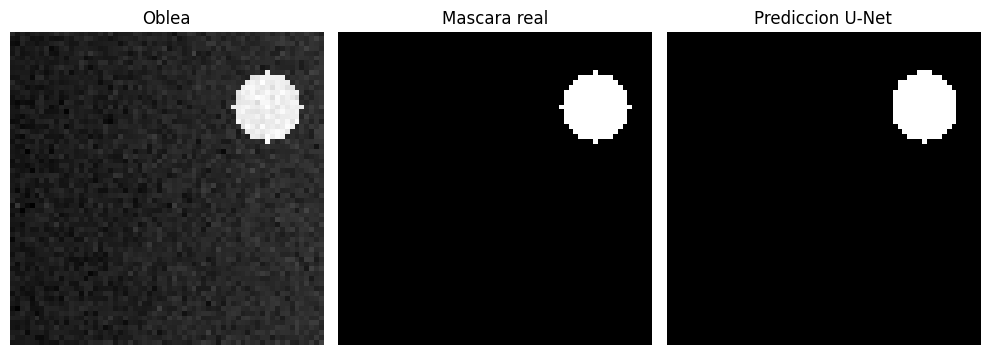

In [12]:
# Calculo de las tres metricas sobre validacion
acc_pixel = (pred_val == Mva_t).float().mean().item()
inter_fg = (pred_val*Mva_t).sum(); union_fg = ((pred_val+Mva_t) > 0).float().sum()
iou_fg = (inter_fg/(union_fg+1e-6)).item()
inter_bg = ((1-pred_val)*(1-Mva_t)).sum(); union_bg = (((1-pred_val)+(1-Mva_t)) > 0).float().sum()
iou_bg = (inter_bg/(union_bg+1e-6)).item()
miou_incl_bg = (iou_fg + iou_bg) / 2

print(f"  Opcion A - pixel accuracy        : {acc_pixel:.3f}")
print(f"  Opcion B - mIoU (incluye fondo)  : {miou_incl_bg:.3f}")
print(f"  Opcion C - IoU de foreground     : {iou_fg:.3f}")

# ============================================================
# [!] FIJE SU ELECCION (por defecto 'C')
# ============================================================
CHOICE_METRIC = "C"   # <-- EDITAR si corresponde

# Visualizacion: imagen, mascara real, prediccion
j = [i for i in range(len(Y_val)) if Y_val[i] == 1][0]
fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(X_val_raw[j], cmap="gray"); ax[0].set_title("Oblea"); ax[0].axis("off")
ax[1].imshow(M_val[j], cmap="gray"); ax[1].set_title("Mascara real"); ax[1].axis("off")
ax[2].imshow(pred_val[j,0].numpy(), cmap="gray"); ax[2].set_title("Prediccion U-Net"); ax[2].axis("off")
plt.tight_layout(); plt.show()

### Justificacion - Bloque 4

> **[!] Cite los tres valores y el porcentaje de pixeles que son fondo en su conjunto.**

- **Mi eleccion:** Opcion `C`
- **Valores observados:** pixel acc = 0.995 | mIoU(incl fondo) = 0.942 | IoU foreground = 0.890
- **Justificacion:** Las otras opciones estan infladas ya que en mi dataset la gran mayoria es fondo. Entonces, la opcion A que mide pixel accuracy estaria midiendo todo, pixel por pixel, prediciendo mas que todo solo fondo. Mientras que la opcion B mide el promedio inlcuyendo fondo, y al fondo dominar la imagen, el porcentaje sera muy alto.
- **Por que descarto las otras dos:** Descarte las otras dos porque la planta nos pide saber que tan bien localizamos los defectos. No le interesa en si el fondo porque ya de por si la imagen es mas que todo fondo. Eso y junto con las razones dadas en el punto anterior, me incline por la opcion C.

## Bloque 5 - Conteo de defectos: post-procesamiento de las propuestas

Para contar e identificar cada defecto, se generan **propuestas de region** a partir del mapa de probabilidad de la U-Net (umbralizando a 0.3, 0.5 y 0.7), lo que produce **cajas solapadas y duplicadas** del mismo defecto. Debe decidir el post-procesamiento que convierte esas propuestas en un conteo:

- **Opcion A - Sin post-procesamiento:** conservar todas las propuestas y contarlas.
- **Opcion B - NMS con IoU = 0.4:** suprimir duplicados manteniendo defectos distintos.
- **Opcion C - NMS y quedarse con la propuesta de mayor area:** reportar a lo sumo un defecto por oblea.

Ejecute: la celda reporta, para cada opcion, el **error de conteo** respecto al ground truth en sus obleas defectuosas. Observe que cada opcion falla por un motivo distinto (o no falla).

In [13]:
def iou_box(a, b):
    x1=max(a[0],b[0]); y1=max(a[1],b[1]); x2=min(a[2],b[2]); y2=min(a[3],b[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    area_a=(a[2]-a[0])*(a[3]-a[1]); area_b=(b[2]-b[0])*(b[3]-b[1])
    return inter/(area_a+area_b-inter+1e-6)

def nms(boxes, scores, thr):
    order=list(np.argsort(scores)[::-1]); keep=[]
    while order:
        i=order.pop(0); keep.append(i)
        order=[j for j in order if iou_box(boxes[i],boxes[j]) < thr]
    return keep

def region_proposals(pmap):
    boxes, scores = [], []
    for thr in (0.3, 0.5, 0.7):
        lbl, nl = ndimage.label(pmap > thr)
        for k in range(1, nl+1):
            ys, xs = np.where(lbl == k)
            if len(xs) < 4: continue
            boxes.append([int(xs.min()),int(ys.min()),int(xs.max()),int(ys.max())])
            scores.append(float(pmap[ys, xs].mean()))
    return boxes, scores

PROBS_NP = PROBS_VAL.squeeze(1).numpy()

def post_process(boxes, scores, mode):
    # A: sin post-procesamiento  | B: NMS IoU=0.4  | C: NMS y solo la caja de mayor area
    if mode == "A":
        return list(range(len(boxes)))
    keep = nms(boxes, scores, 0.4)
    if mode == "C" and keep:
        areas = [ (boxes[i][2]-boxes[i][0])*(boxes[i][3]-boxes[i][1]) for i in keep ]
        return [ keep[int(np.argmax(areas))] ]
    return keep

def eval_count(mode):
    count_err, gt_total, raw_props = 0, 0, 0
    for i in range(len(X_val_raw)):
        if Y_val[i] == 0: continue
        bxs, scs = region_proposals(PROBS_NP[i]); raw_props += len(bxs)
        kept = post_process(bxs, scs, mode)
        count_err += abs(len(kept) - len(B_val[i])); gt_total += len(B_val[i])
    return raw_props, count_err, gt_total

for k in ["A","B","C"]:
    rp, ce, gt = eval_count(k)
    print(f"  Opcion {k}: propuestas_crudas={rp} | error_de_conteo={ce} | defectos_reales={gt}")

# ============================================================
# [!] FIJE SU ELECCION (por defecto 'B')
# ============================================================
CHOICE_NMS = "B"   # <-- EDITAR si corresponde

  Opcion A: propuestas_crudas=117 | error_de_conteo=61 | defectos_reales=60
  Opcion B: propuestas_crudas=117 | error_de_conteo=21 | defectos_reales=60
  Opcion C: propuestas_crudas=117 | error_de_conteo=36 | defectos_reales=60


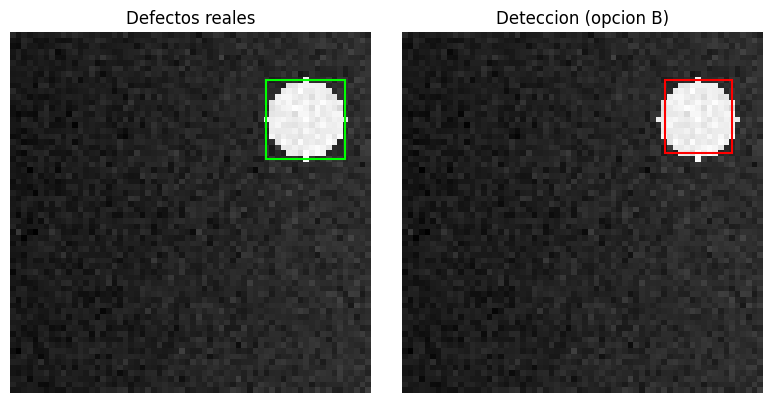

Defectos reales en oblea #2: 1 | detectados con opcion B: 1


In [14]:
# Visualizacion del resultado con la opcion elegida sobre una oblea
import matplotlib.patches as patches
j = [i for i in range(len(Y_val)) if Y_val[i] == 1][0]
bxs, scs = region_proposals(PROBS_NP[j])
kept = post_process(bxs, scs, CHOICE_NMS)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(X_val_raw[j], cmap="gray"); ax[0].set_title("Defectos reales"); ax[0].axis("off")
for b in B_val[j]:
    ax[0].add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1], fill=False, edgecolor="lime", lw=1.5))
ax[1].imshow(X_val_raw[j], cmap="gray"); ax[1].set_title(f"Deteccion (opcion {CHOICE_NMS})"); ax[1].axis("off")
for ki in kept:
    b = bxs[ki]
    ax[1].add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1], fill=False, edgecolor="red", lw=1.5))
plt.tight_layout(); plt.show()
print(f"Defectos reales en oblea #{j}: {len(B_val[j])} | detectados con opcion {CHOICE_NMS}: {len(kept)}")

### Visualización de detecciones para todas las obleas defectuosas en el conjunto de validación

### Justificacion - Bloque 5

> **[!] Cite el error de conteo de cada opcion en SU conjunto.**

- **Mi eleccion:** Opcion `B`
- **Error de conteo observado por opcion:** A: 61 | B: 21 | C: 36
- **Justificacion:** Elegi la opcion B ya que el algoritmo NMS elimina las detecciones redundantes cuando presentan un IoU elevado, conservando unicamente la propuesta mas representativa. De esta forma, multiples cajas correspondientes a un mismo defecto se agrupan en una sola deteccion mientras que auquellos defectos fisicamente distintos continuan siendo contabilizados por separado.
- **Por que descarto las otras dos:** Descarte la opcion A ya que este presenta un sobre conteo. Al existir propuestas que provienen de varios umbrales, un mismo defecto podria aparecer varias veces con cajas diferentes. Contar todas, produciria un numero superior al real. Y con respecto a la opcion C, se descarta porque produce subconteo. Esta estrategia fuerza que cada oblea tenga como maximo un defecto reportado, incluso cuando existen varios defectos independientes.

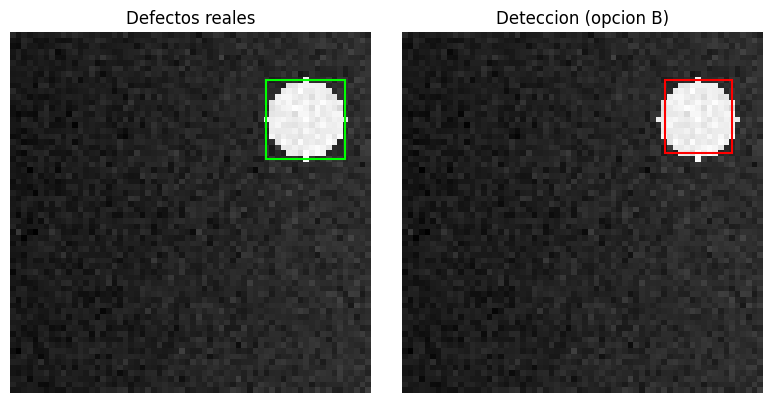

Oblea #2: Defectos reales = 1 | Detectados con opcion B = 1


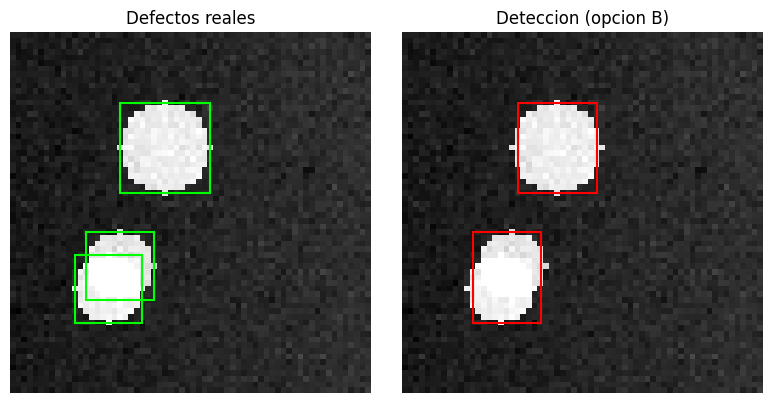

Oblea #5: Defectos reales = 3 | Detectados con opcion B = 2


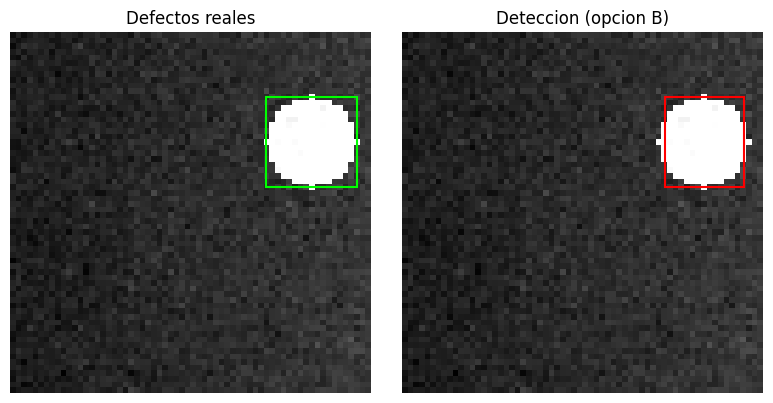

Oblea #6: Defectos reales = 1 | Detectados con opcion B = 1


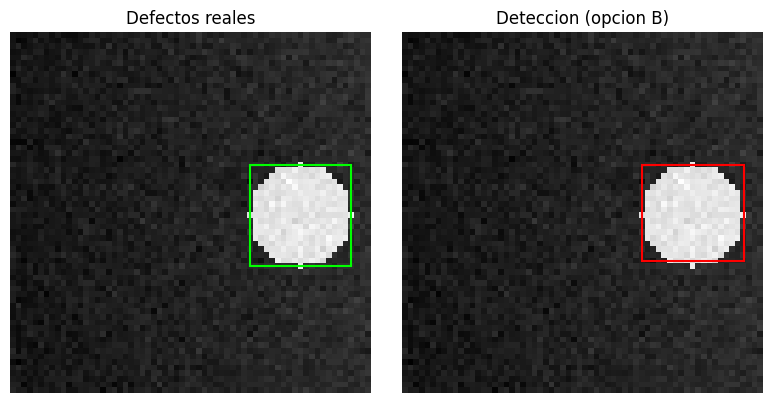

Oblea #7: Defectos reales = 1 | Detectados con opcion B = 1


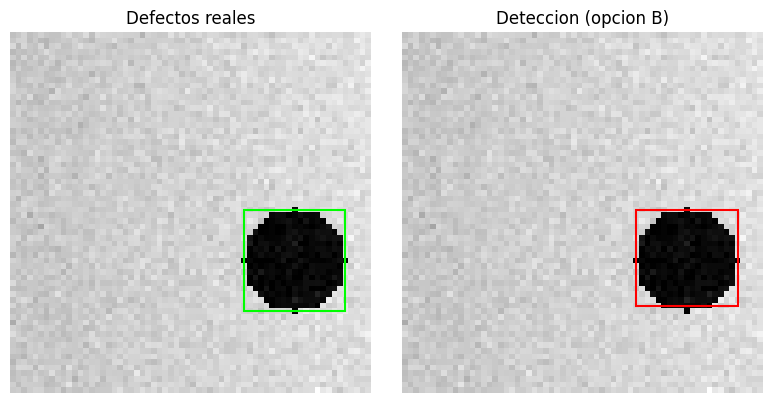

Oblea #9: Defectos reales = 1 | Detectados con opcion B = 1


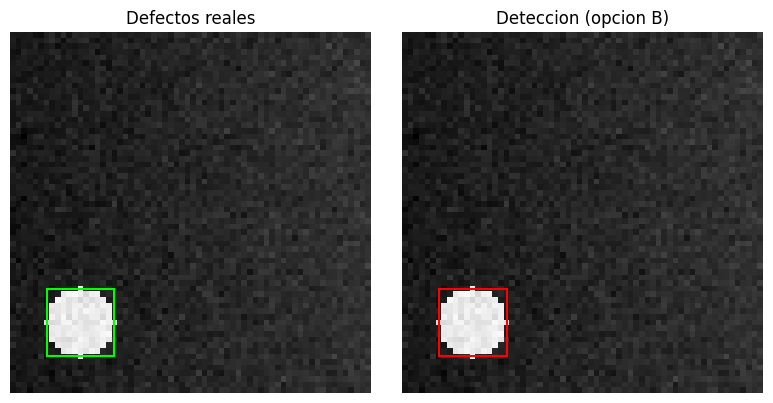

Oblea #10: Defectos reales = 1 | Detectados con opcion B = 1


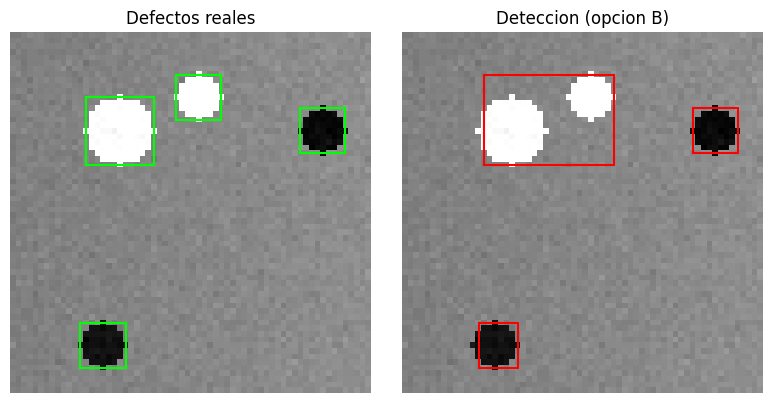

Oblea #11: Defectos reales = 4 | Detectados con opcion B = 3


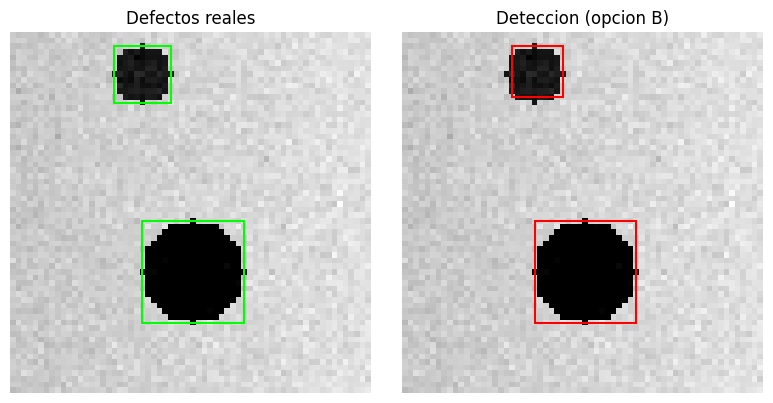

Oblea #12: Defectos reales = 2 | Detectados con opcion B = 2


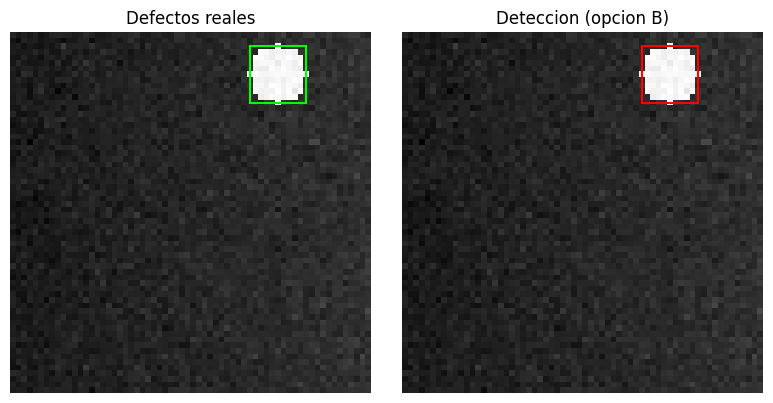

Oblea #13: Defectos reales = 1 | Detectados con opcion B = 1


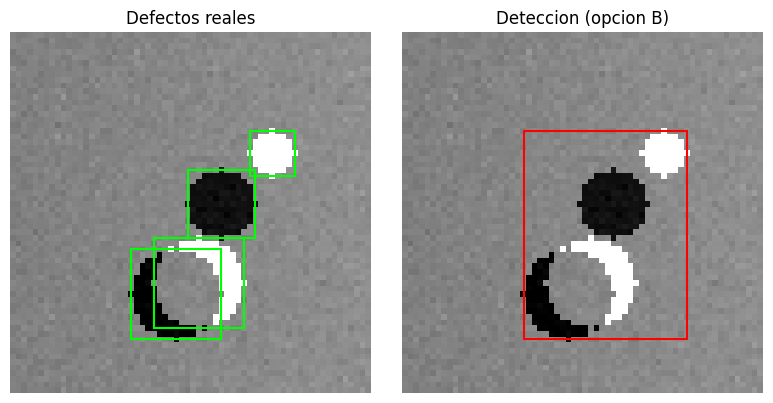

Oblea #15: Defectos reales = 4 | Detectados con opcion B = 1


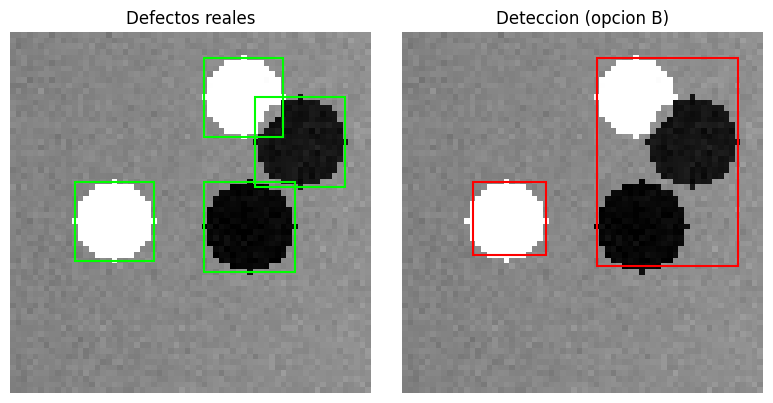

Oblea #16: Defectos reales = 4 | Detectados con opcion B = 2


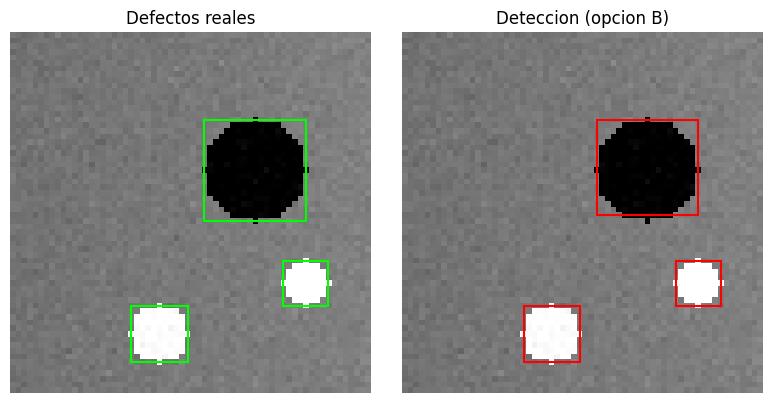

Oblea #17: Defectos reales = 3 | Detectados con opcion B = 3


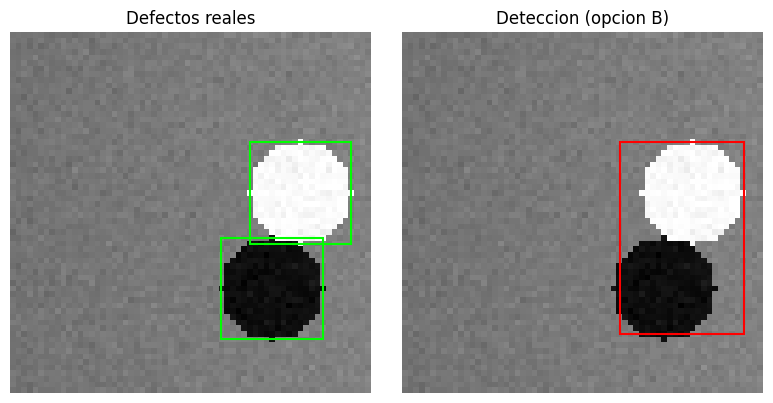

Oblea #18: Defectos reales = 2 | Detectados con opcion B = 1


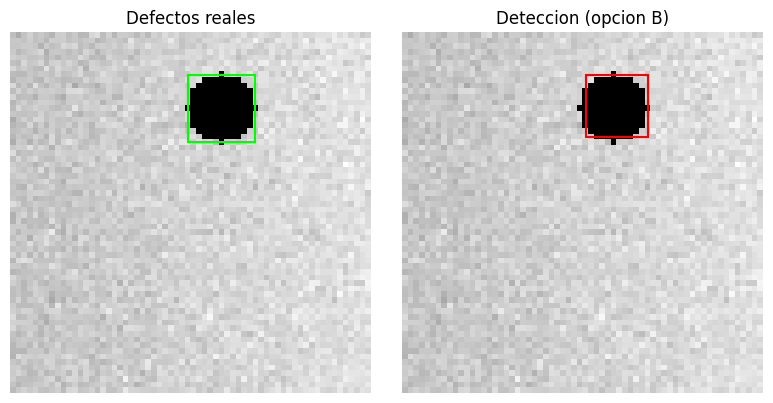

Oblea #20: Defectos reales = 1 | Detectados con opcion B = 1


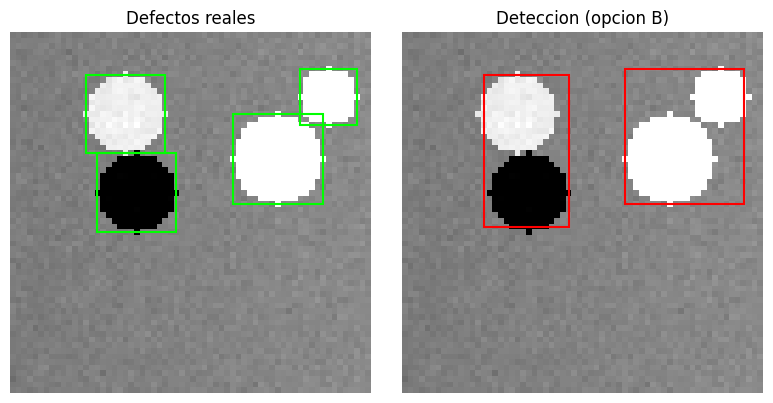

Oblea #21: Defectos reales = 4 | Detectados con opcion B = 2


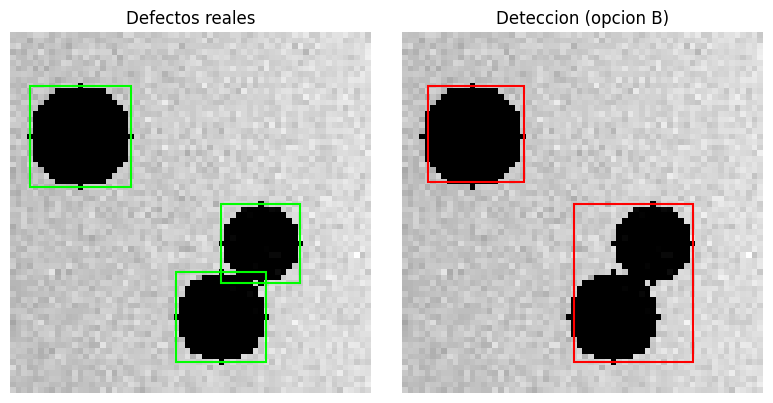

Oblea #22: Defectos reales = 3 | Detectados con opcion B = 2


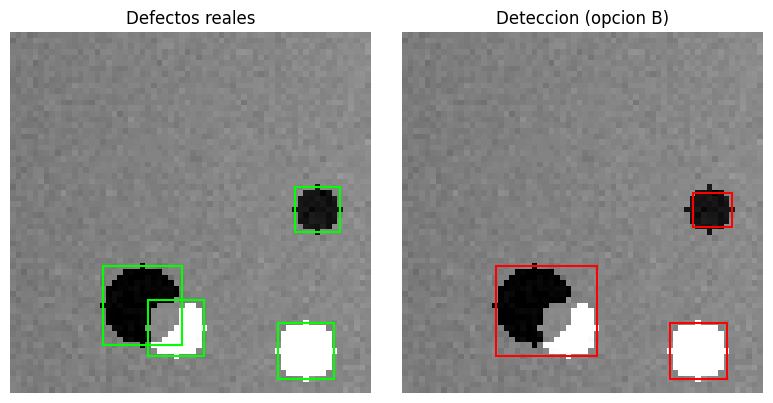

Oblea #30: Defectos reales = 4 | Detectados con opcion B = 3


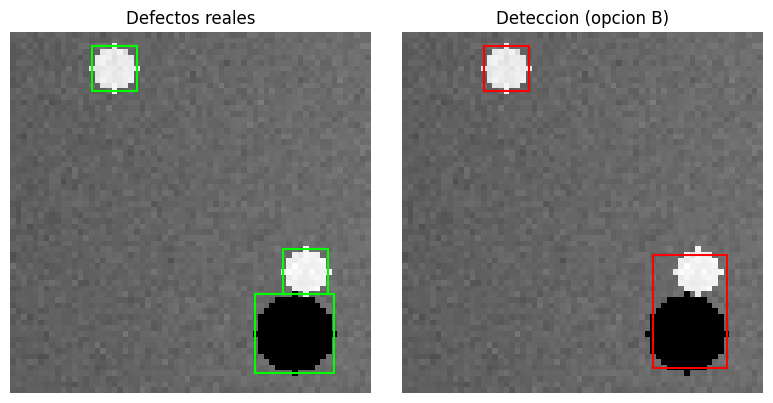

Oblea #33: Defectos reales = 3 | Detectados con opcion B = 2


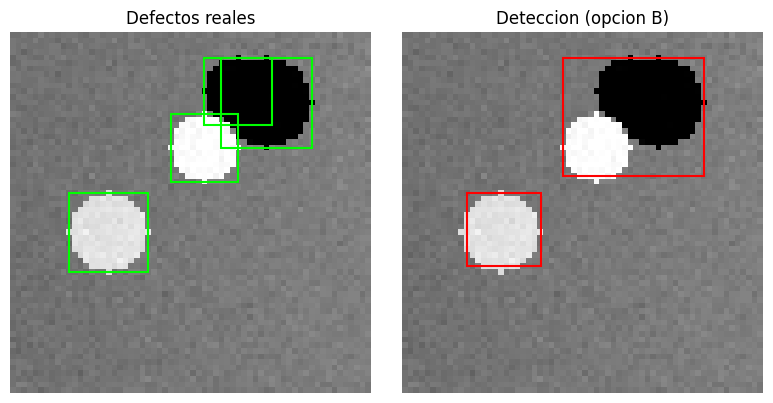

Oblea #38: Defectos reales = 4 | Detectados con opcion B = 2


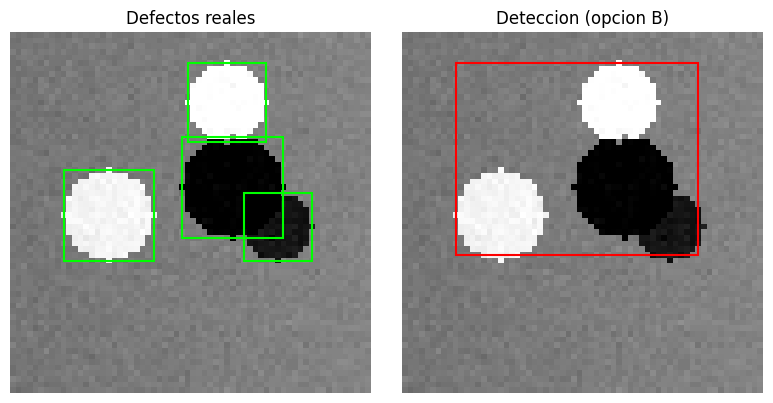

Oblea #41: Defectos reales = 4 | Detectados con opcion B = 1


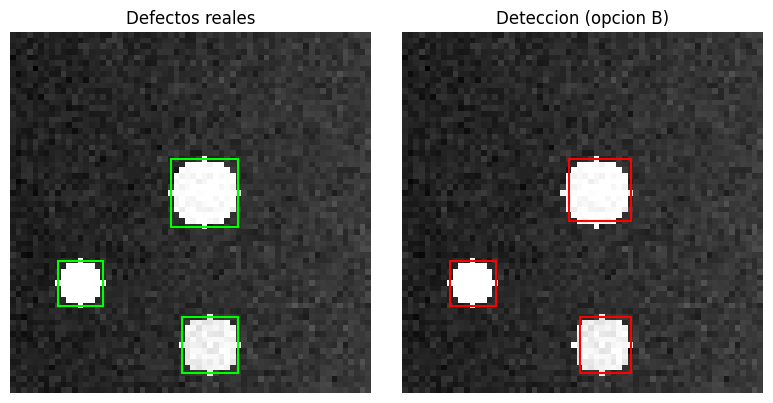

Oblea #42: Defectos reales = 3 | Detectados con opcion B = 3


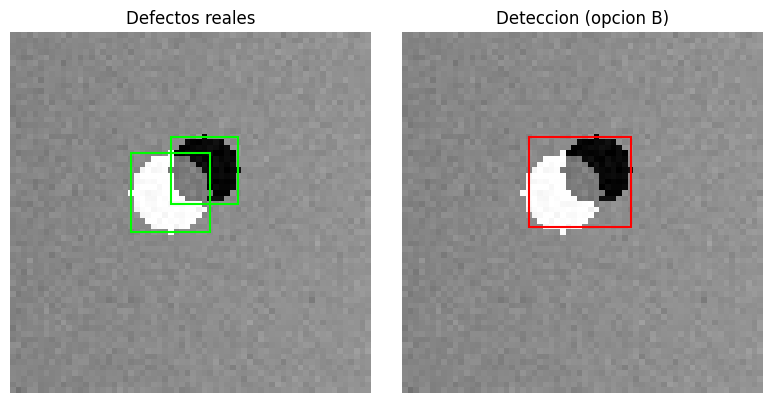

Oblea #43: Defectos reales = 2 | Detectados con opcion B = 1


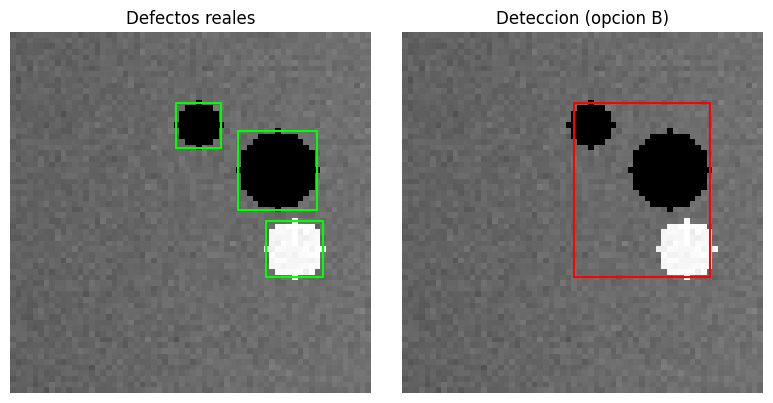

Oblea #47: Defectos reales = 3 | Detectados con opcion B = 1


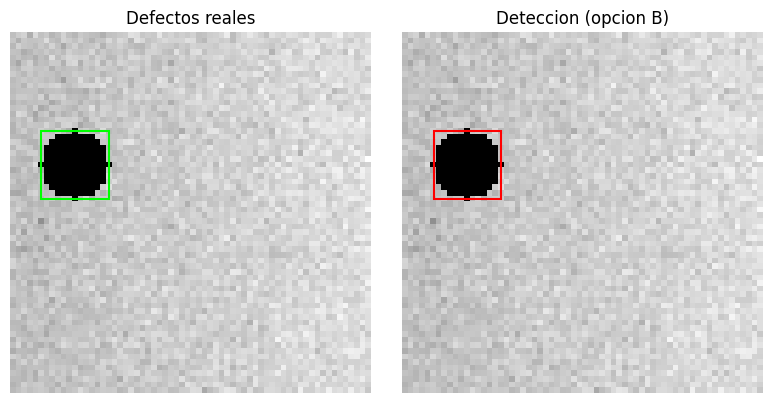

Oblea #49: Defectos reales = 1 | Detectados con opcion B = 1


In [15]:
import matplotlib.patches as patches

defective_wafer_indices = [i for i, is_defective in enumerate(Y_val) if is_defective == 1]

for j in defective_wafer_indices:
    bxs, scs = region_proposals(PROBS_NP[j])
    kept = post_process(bxs, scs, CHOICE_NMS)

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(X_val_raw[j], cmap="gray"); ax[0].set_title("Defectos reales"); ax[0].axis("off")
    for b in B_val[j]:
        ax[0].add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1], fill=False, edgecolor="lime", lw=1.5))

    ax[1].imshow(X_val_raw[j], cmap="gray"); ax[1].set_title(f"Deteccion (opcion {CHOICE_NMS})"); ax[1].axis("off")
    for ki in kept:
        b = bxs[ki]
        ax[1].add_patch(patches.Rectangle((b[0],b[1]), b[2]-b[0], b[3]-b[1], fill=False, edgecolor="red", lw=1.5))

    plt.tight_layout(); plt.show()
    print(f"Oblea #{j}: Defectos reales = {len(B_val[j])} | Detectados con opcion {CHOICE_NMS} = {len(kept)}")


## Reflexion contextual

Responda a partir de SU ejecucion (no es generica):

1. Identifique en su conjunto de validacion **una oblea defectuosa cuyo defecto haya sido mas dificil de detectar** (revise las figuras). Indique el indice y describa por que cree que fue dificil (tamano, contraste, cercania a un borde).

  - La oblea defectuosa cuyo defecto fue mas dificl de detectar fue la #41. En esa imagen existen cuatro defectos reales pero solo se detecto 1. Esto ocurrio porque varios defectos se encuentran muy cerca el uno del otro, debido a esto las regiones segmentadas terminaron fusionandose en una unica caja conectada.

2. Si la planta exige **no dejar pasar ninguna oblea defectuosa** (prioriza recall sobre precision), >como ajustaria el umbral de decision de su clasificador y/o de su segmentacion? Justifique con el comportamiento que observo.

  - Si ese fuera el caso entonces se debe priorizar el recall aunque aumenten los falsos positivos. Para lograr eso, reduciria el umbral de decision tanto en el clasificador como en la segmentacion. En la etapa de clasificacion utilizaria un umbral de 0.3 o 0.4 para que las obleas sean clasificadas como defectuosas y disminuiria el numero de falsos negativos. Con respecto a la etapa de segmentacion, tambien se reduciria el umbral pero aplicado al mapa de probabilidades. Un umbral mas bajo permite detectar regiones defectuosas mas pequeñas incrementando el recall de la segmentacion

3. Conecte las tres etapas: >por que una mala eleccion en el Bloque 3 (perdida) degradaria tambien el resultado del Bloque 5 (conteo)?

  - Si la perdida de segmentacion no penaliza adecuadamente la forma y el solapamiento de las regiones defectuosas entonces la U-Net podria generar mascaras imprecisas o excesivamente conectadas. Como el conteo en el bloque 5 depende directamente de estas mascaras, cualquier error de segmentacion seria un error de conteo y deteccion.

# Declaracion uso de IA
Use la IA para poder visualizar todas las detecciones del conjunto de validacion. Que es necesario para responder el ultimo bloque de reflexion contextual.